# 03. Modeling & Evaluation (Regression)
- 타깃: `log10(cycle_life)` → 예측 후 `10^` 역변환하여 사이클 단위 **MAPE** 로 평가
- **Batch 1 → Train / Valid(Hold-out)**, **Batch 2 → Test** (Batch 3 는 추가 과제, 별도 진행)
- 검증은 **충전 정책(프로토콜) 단위 분리**: 같은 정책의 셀이 Train 과 Valid 에 동시에 들어가지 않도록 함

> 실행: `python -m src.train --eval-batches 2` 와 동일한 결과를 단계별로 보여 줍니다. Batch 2 는 모델 선택에 쓰지 않고 선택이 끝난 뒤 평가에만 사용했습니다.

In [1]:
import sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))          # 저장소 루트 (src/ 임포트용)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.font_manager as fm
for f in ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]:
    if f in {x.name for x in fm.fontManager.ttflist}: plt.rcParams["font.family"] = f; break
plt.rcParams.update({"axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "figure.dpi": 110})
pd.set_option("display.width", 200); pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
ROOT = Path.cwd().parent; FIG = ROOT / "results" / "figures"

In [2]:
from src.train import load_data, compare_models, FEATURE_SETS, STAGES
from src.validation import group_holdout
df = load_data(ROOT / "data"); b1 = df[df.batch == 1].reset_index(drop=True)
tr_i, va_i, chosen = group_holdout(b1, 42)
TR, VA = b1.loc[tr_i].reset_index(drop=True), b1.loc[va_i].reset_index(drop=True)
assert set(TR.policy).isdisjoint(VA.policy)
print(f"Batch1 {len(b1)}셀 / 정책 {b1.policy.nunique()}개  →  Train {len(TR)}셀 ({TR.policy.nunique()}정책), Valid {len(VA)}셀 ({VA.policy.nunique()}정책)")
print("Valid 정책:", chosen); print("Valid 수명:", sorted(VA.cycle_life.astype(int))); print("Train 수명 범위:", int(TR.cycle_life.min()), "~", int(TR.cycle_life.max()))

Batch1 41셀 / 정책 22개  →  Train 32셀 (17정책), Valid 9셀 (5정책)
Valid 정책: ['5.4C(60%)-3C', '4C(80%)-4C', '5.4C(70%)-3C', '5.4C(40%)-3.6C', '8C(35%)-3.6C']
Valid 수명: [599, 616, 691, 719, 788, 880, 1054, 1226, 1227]
Train 수명 범위: 534 ~ 1190


## 1. 검증 설계 변경 근거 (Day 1 → Day 2): 랜덤 CV vs 정책 단위 CV
Batch 1 은 정책 22개 × 셀 1~3개 구조입니다. 셀 단위 랜덤 분할은 같은 정책의 형제 셀을 학습에서 보여 줍니다. 같은 모델·피처로 두 방식을 비교합니다.

,featset,model,n_feat,CV_group,CV_group_sd,CV_random,CV_random_sd,CV_extrap,score_stage2,Valid
0,D6 dQ4+QD2+QDmax,GPR,6,8.900,3.400,8.200,2.200,14.600,11.800,6.900
1,V1 var,GPR,1,11.400,4.900,8.300,2.300,15.700,13.600,9.200
2,V1 var,GBM(d=2),1,11.900,4.000,11.200,3.100,17.800,14.900,11.000
3,D4 dQ4,GPR,4,12.000,4.800,9.700,2.700,18.300,15.100,10.000
4,V2 var+min,GPR,2,12.700,4.800,9.300,2.800,19.900,16.300,9.500
5,V2 var+min,GBM(d=2),2,12.900,4.200,12.100,3.500,18.800,15.900,10.300
6,S7 dQ4+chg+Tavg+IRmin,GBM(d=2),7,13.500,4.500,10.500,3.100,23.000,18.300,11.000
7,D6 dQ4+QD2+QDmax,GBM(d=2),6,13.600,5.500,12.400,3.800,22.500,18.100,7.900
8,D4 dQ4,GBM(d=2),4,15.000,5.100,12.800,3.800,24.100,19.600,10.700
9,V1 var,Linear,1,15.300,9.900,10.900,2.600,20.000,17.600,11.400


정책 단위 CV 가 랜덤 CV 보다 나쁜 조합: 27/27, 평균 차이 4.0%p


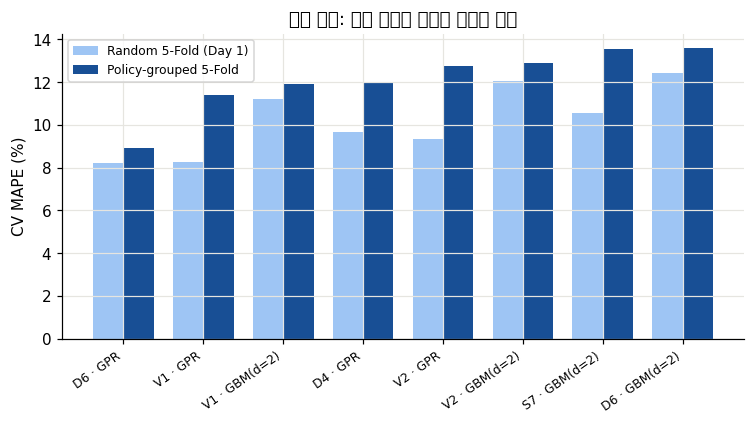

In [3]:
cv = compare_models(TR, VA).sort_values("CV_group").reset_index(drop=True)
display(cv.round(1))
gap = (cv.CV_group - cv.CV_random)
print(f"정책 단위 CV 가 랜덤 CV 보다 나쁜 조합: {(gap > 0).sum()}/{len(cv)}, 평균 차이 {gap.mean():.1f}%p")
top = cv.head(8); lab = top.featset.str.split().str[0] + " · " + top.model
fig, ax = plt.subplots(figsize=(8, 3.6)); x = np.arange(len(top)); w = .38
ax.bar(x - w/2, top.CV_random, w, color="#9ec5f4", label="Random 5-Fold (Day 1)"); ax.bar(x + w/2, top.CV_group, w, color="#184f95", label="Policy-grouped 5-Fold")
ax.set_xticks(x, lab, rotation=35, ha="right", fontsize=8); ax.set_ylabel("CV MAPE (%)"); ax.legend(fontsize=8); ax.set_title("랜덤 분할: 정책 단위로 나누면 오차가 커짐")
fig.savefig(FIG / "cv_random_vs_group.png", dpi=180, bbox_inches="tight"); plt.show()

**바꾼 이유**
 "Day 1에는 셀 단위 랜덤 분할을 계획했지만, 같은 충전 프로토콜의 셀이 Train/Valid에 나뉘면 누수 위험이 있다는 점을 확인했다. 실제로 같은 모델에서 정책 단위 CV가 랜덤 CV보다 평균 4.0%p 나빠서(27개 조합 전부), 랜덤 분할이 낙관적임을 확인하고 정책 단위로 바꿨다."

## 2. 모델 선택 (Train 안에서만)
- **1차 (사전 확정)**: 정책 단위 CV MAPE 최소
- **개선 단계**: Test 결과를 본 뒤, Batch 1 안에서만 **외삽 CV**(수명이 가장 짧은 정책 20·25·30% 를 검증으로) 를 설계하고 `(정책 단위 CV + 외삽 CV)/2` 최소로 재선택. 선택 규칙은 외삽 CV 값을 보기 전에 고정함.

In [4]:
for s, (label, key) in STAGES.items():
    b = cv.sort_values(key).iloc[0]
    print(f"{label:26s} 기준={key:13s} → {b.featset} / {b.model}   CV_group={b.CV_group:.1f}  CV_extrap={b.CV_extrap:.1f}")
display(cv.sort_values("score_stage2")[["featset", "model", "CV_group", "CV_extrap", "score_stage2", "Valid"]].head(10).round(1))

1차 (사전 확정)                 기준=CV_group      → D6 dQ4+QD2+QDmax / GPR   CV_group=8.9  CV_extrap=14.6
개선 후 (외삽 검증 반영)            기준=score_stage2  → D6 dQ4+QD2+QDmax / GPR   CV_group=8.9  CV_extrap=14.6


,featset,model,CV_group,CV_extrap,score_stage2,Valid
0,D6 dQ4+QD2+QDmax,GPR,8.900,14.600,11.800,6.900
1,V1 var,GPR,11.400,15.700,13.600,9.200
2,V1 var,GBM(d=2),11.900,17.800,14.900,11.000
3,D4 dQ4,GPR,12.000,18.300,15.100,10.000
5,V2 var+min,GBM(d=2),12.900,18.800,15.900,10.300
4,V2 var+min,GPR,12.700,19.900,16.300,9.500
12,D6 dQ4+QD2+QDmax,PLS(2),16.600,16.400,16.500,9.100
9,V1 var,Linear,15.300,20.000,17.600,11.400
7,D6 dQ4+QD2+QDmax,GBM(d=2),13.600,22.500,18.100,7.900
6,S7 dQ4+chg+Tavg+IRmin,GBM(d=2),13.500,23.000,18.300,11.000


## 3. 성능

In [5]:
perf = pd.read_csv(ROOT / "results" / "model_performance.csv"); display(perf)
display(pd.read_csv(ROOT / "results" / "baseline_vs_final.csv"))

,구분,1차 MAPE (%),개선 후 MAPE (%),비고 (개선 후)
0,Train (Batch 1 CV),8.900,8.900,"정책단위 Repeated 5-Fold x10, SD=3.4"
1,Valid (Batch 1 Hold-out),6.900,6.900,정책단위 Hold-out 9셀; 30개 시드 평균 7.6+-2.0 (범위 4.1~1...
2,Test (Batch 2),38.500,38.500,"Batch1 전체(41셀) 재학습, n=39; Train(32)만 학습 시 37.3"
3,Gap (Train-Valid),-2.000,-2.000,(+) : 과적합 의심 [Valid - Train]
4,Gap (Valid-Test),31.600,31.600,(+) : 배치간 일반화 저하 의심 [Test - Valid]
5,Gap (Target-Test),29.400,29.400,Target : 원논문 9.1% [Test - Target]


,model,train_cv,valid,test_b2
0,V1 var / Linear (논문 Variance baseline),15.300,11.400,36.000
1,D6 dQ4+QD2+QDmax / GPR (1차 (사전 확정)),8.900,6.900,38.500
2,D6 dQ4+QD2+QDmax / GPR (개선 후 (외삽 검증 반영)),8.900,6.900,38.500


## 4. 오류 분석 (Batch 2)

예측값 범위 525~1192 (Train 최소 534) | 실제보다 길게 예측한 셀 92%


,셀수,MAPE,평균편향
life_bucket,,,
<450,15,45.900,45.900
450-550,15,43.700,43.700
550-800,2,38.800,38.800
>800,7,11.200,5.000


,셀수,MAPE,평균편향
new_structure,,,
False,30,44.800,44.800
True,9,17.400,12.500


,cell_id,policy,cycle_life,pred,ape
10,b2c6,3.6C(9%)-5C,393.000,683.800,74.000
24,b2c29,5.2C(58%)-4C,452.000,745.700,65.000
21,b2c11,5.2C(50%)-4.25C,449.000,692.900,54.300
31,b2c0,5.2C(58%)-4C,477.000,734.800,54.100
39,b2c7,4.8C(80%)-4.8C-newstructure,777.000,"1,191.900",53.400
12,b2c21,6C(60%)-3C,408.000,624.200,53.000
14,b2c5,3.6C(30%)-6C,416.000,632.400,52.000
36,b2c3,4.65C(44%)-5C,499.000,740.400,48.400


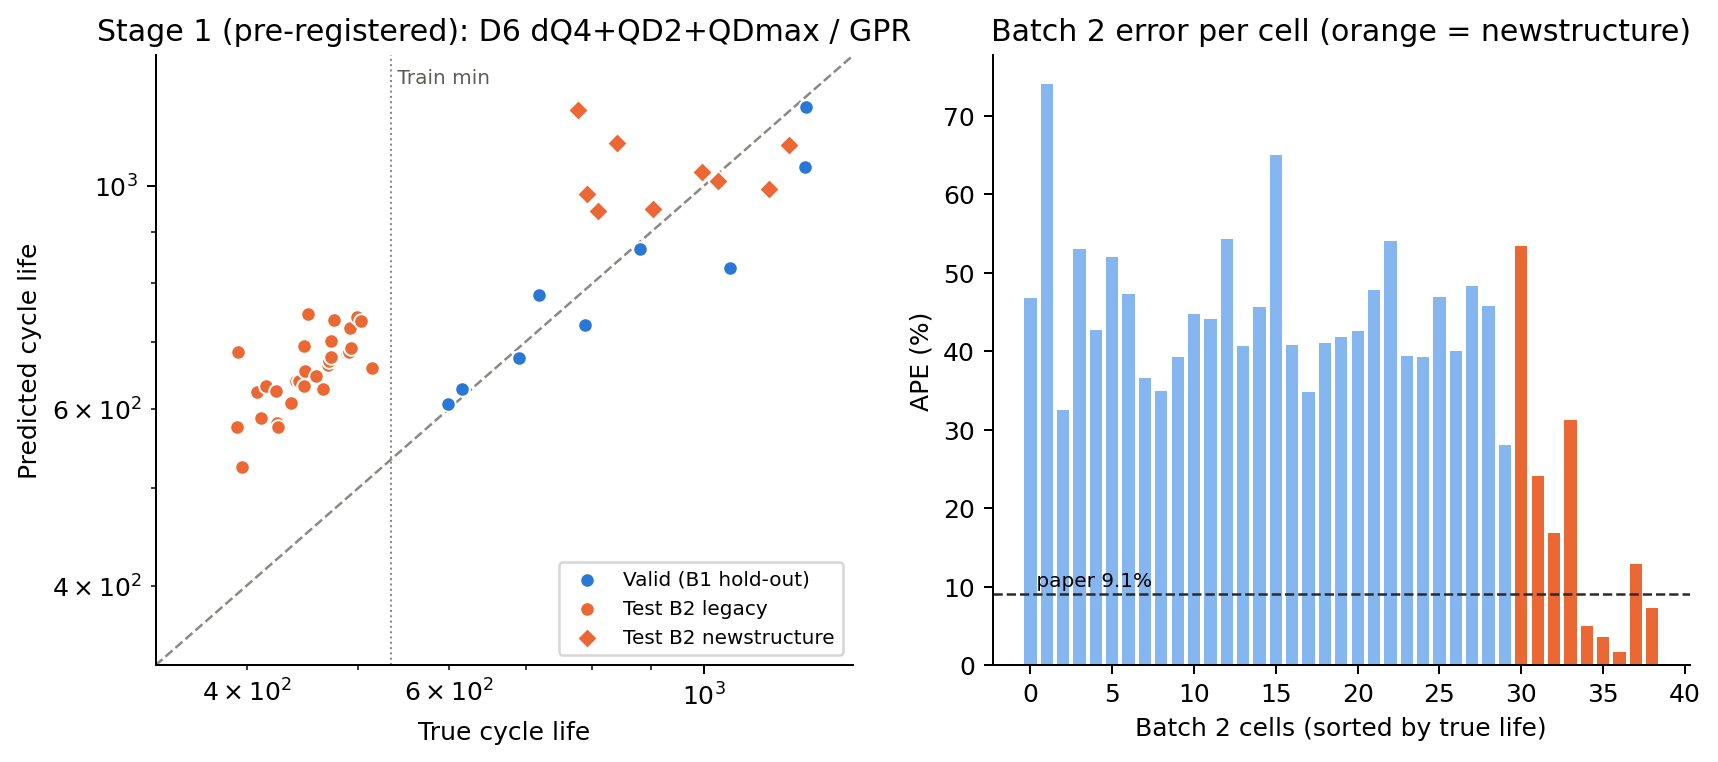

In [6]:
P = pd.read_csv(ROOT / "results" / "stage1" / "predictions.csv"); T = P[P.split == "Test(B2)"].copy()
T["signed_%"] = (T.pred - T.cycle_life) / T.cycle_life * 100
print(f"예측값 범위 {T.pred.min():.0f}~{T.pred.max():.0f} (Train 최소 {b1.cycle_life.min():.0f}) | 실제보다 길게 예측한 셀 {(T['signed_%'] > 0).mean():.0%}")
T["life_bucket"] = pd.cut(T.cycle_life, [0, 450, 550, 800, 1300], labels=["<450", "450-550", "550-800", ">800"])
display(T.groupby("life_bucket", observed=True).agg(셀수=("ape", "size"), MAPE=("ape", "mean"), 평균편향=("signed_%", "mean")).round(1))
display(T.groupby("new_structure").agg(셀수=("ape", "size"), MAPE=("ape", "mean"), 평균편향=("signed_%", "mean")).round(1))
display(T.sort_values("ape", ascending=False).head(8)[["cell_id", "policy", "cycle_life", "pred", "ape"]].round(1))
from IPython.display import Image; display(Image(str(FIG / "pred_vs_true_stage1.png")))